# 💧 Model 2 — Durasi Penyiraman (ESP32 TFLite)

**Input :** `kelembapan_tanah, kelembapan_udara, suhu, vpd, ec_aktual, debit_pompa, fase`  
**Output:** `durasi_penyiraman` (detik)

**Catatan penting:**
- Pupuk (A/B mix) sudah tercampur di air yang digunakan untuk menyiram
- `debit_pompa` (L/menit) adalah input karena debit menentukan **volume air** yang keluar per detik
- Durasi dikalibrasi agar volume pupuk yang masuk ke media tidak over-fertilisasi

**Strategi TFLite:**  
RF tidak bisa langsung di-export ke TFLite. Solusinya:  
① Train RF → ② Gunakan prediksi RF sebagai label → ③ Latih Neural Network kecil → ④ Export ke `.tflite` dengan **int8 quantization** buat ESP32

## Cell 1 — Install & Import
```bash
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow
```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

print(f'✅ TensorFlow v{tf.__version__}')

✅ TensorFlow v2.16.2


## Cell 2 — Generate Dataset Durasi Penyiraman

**Logika labeling:**

| Kondisi | Efek Durasi |
|---|---|
| Kelembapan tanah < 50% | Tambah durasi (defisit besar) |
| VPD > 1.2 kPa | Tambah 30% (transpirasi tinggi) |
| VPD < 0.5 kPa | Kurangi 20% (transpirasi rendah) |
| EC aktual > target × 1.2 | Kurangi 30% (cegah over-fertilisasi) |
| Debit pompa besar | Durasi lebih pendek (volume = debit × durasi) |

In [3]:
n_samples = 2000
np.random.seed(42)

fase = np.random.choice([0, 1], n_samples, p=[0.55, 0.45])
is_veg = (fase == 0)

# ── Sensor lingkungan ──
suhu = np.where(is_veg,
    np.random.normal(26.5, 2.0, n_samples),
    np.random.normal(28.5, 2.2, n_samples)).clip(20, 35)

kelembapan_udara = np.clip(
    85 - 0.9*(suhu-25) + np.random.normal(0, 5, n_samples), 40, 95)

kelembapan_tanah = np.random.uniform(25, 90, n_samples)  # % kelembapan media

# VPD
es  = 0.6108 * np.exp((17.27*suhu)/(suhu+237.3))
vpd = (es - es*(kelembapan_udara/100)).round(4)

# EC aktual larutan nutrisi di air penyiram
base_ec    = np.where(is_veg, 1.6, 2.0)
ec_aktual  = np.clip(base_ec + np.random.normal(0, 0.15, n_samples), 0.8, 3.5).round(3)

# Debit pompa (L/menit) — bervariasi sesuai spesifikasi pompa di lapangan
debit_pompa = np.random.uniform(1.0, 5.0, n_samples).round(2)

# ── Hitung durasi penyiraman (detik) ──
def hitung_durasi(kelembapan_tanah_, vpd_, ec_aktual_, debit_, fase_):
    durasi = np.zeros(len(kelembapan_tanah_))
    target_ec = np.where(fase_ == 0, 1.6, 2.0)
    kelembapan_target = 70.0  # % target kelembapan media

    for i in range(len(kelembapan_tanah_)):
        defisit = max(0, kelembapan_target - kelembapan_tanah_[i])

        # Volume air yang dibutuhkan (L) — 0.04 L per % defisit (empiris)
        volume_kebutuhan = defisit * 0.04

        # Koreksi VPD
        if vpd_[i] > 1.2:
            volume_kebutuhan *= 1.30   # transpirasi tinggi
        elif vpd_[i] < 0.5:
            volume_kebutuhan *= 0.80   # transpirasi rendah

        # Koreksi EC — jika EC terlalu tinggi, kurangi penyiraman
        # agar tidak kelebihan pupuk di media
        if ec_aktual_[i] > target_ec[i] * 1.2:
            volume_kebutuhan *= 0.70

        # Durasi = Volume / Debit (menit → detik)
        d = (volume_kebutuhan / debit_[i]) * 60  # detik
        durasi[i] = np.clip(d, 10, 600)           # batas 10–600 detik

    return durasi

durasi_base = hitung_durasi(
    kelembapan_tanah, vpd, ec_aktual, debit_pompa, fase)

# Tambah noise realistis (variasi kondisi media tidak seragam)
durasi_label = np.clip(
    durasi_base + np.random.normal(0, 8, n_samples), 10, 600).round(1)

df = pd.DataFrame({
    'kelembapan_tanah' : kelembapan_tanah.round(2),
    'kelembapan_udara' : kelembapan_udara.round(2),
    'suhu'             : suhu.round(2),
    'vpd'              : vpd,
    'ec_aktual'        : ec_aktual,
    'debit_pompa'      : debit_pompa,
    'fase'             : fase,
    'durasi_detik'     : durasi_label
})

df.to_csv('dataset_durasi_penyiraman.csv', index=False)
print(f'✅ Dataset disimpan: {df.shape}')
display(df.describe().round(2))

✅ Dataset disimpan: (2000, 8)


,kelembapan_tanah,kelembapan_udara,suhu,vpd,ec_aktual,debit_pompa,fase,durasi_detik
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,57.78,82.72,27.34,0.64,1.78,2.99,0.46,20.42
std,18.63,5.47,2.30,0.25,0.25,1.16,0.50,14.42
min,25.02,64.63,20.46,0.13,1.01,1.00,0.00,10.00
25%,41.57,79.07,25.79,0.46,1.58,1.98,0.00,10.00
50%,57.72,82.80,27.34,0.62,1.76,2.98,0.00,14.90
75%,74.08,86.57,28.94,0.80,1.98,4.04,1.00,24.80
max,89.98,95.00,34.96,1.76,2.42,5.00,1.00,105.00


## Cell 3 — EDA Singkat

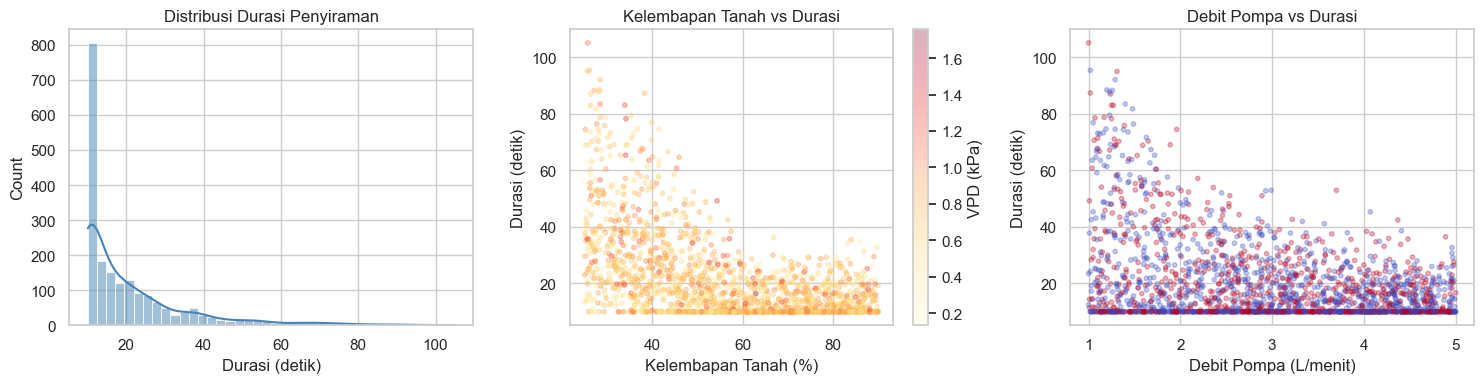

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi durasi
sns.histplot(df['durasi_detik'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Durasi Penyiraman', fontsize=12)
axes[0].set_xlabel('Durasi (detik)')

# Scatter kelembapan vs durasi
sc = axes[1].scatter(df['kelembapan_tanah'], df['durasi_detik'],
                     c=df['vpd'], cmap='YlOrRd', alpha=0.3, s=10)
plt.colorbar(sc, ax=axes[1], label='VPD (kPa)')
axes[1].set_xlabel('Kelembapan Tanah (%)')
axes[1].set_ylabel('Durasi (detik)')
axes[1].set_title('Kelembapan Tanah vs Durasi', fontsize=12)

# Scatter debit vs durasi
axes[2].scatter(df['debit_pompa'], df['durasi_detik'],
                c=df['fase'], cmap='coolwarm', alpha=0.3, s=10)
axes[2].set_xlabel('Debit Pompa (L/menit)')
axes[2].set_ylabel('Durasi (detik)')
axes[2].set_title('Debit Pompa vs Durasi', fontsize=12)

plt.tight_layout()
plt.savefig('eda_durasi.png', dpi=150)
plt.show()

## Cell 4 — Tahap ① : Train Random Forest
RF dipakai untuk mendapatkan prediksi yang "lebih halus" daripada rule-based murni. Prediksi RF ini yang jadi label untuk melatih NN.

In [5]:
FEATURES = ['kelembapan_tanah', 'kelembapan_udara', 'suhu',
             'vpd', 'ec_aktual', 'debit_pompa', 'fase']
TARGET   = 'durasi_detik'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators     = 200,
    max_depth        = 14,
    min_samples_leaf = 3,
    max_features     = 'sqrt',
    random_state     = 42,
    n_jobs           = -1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'=== Evaluasi RF ===')
print(f'MAE  : {mae_rf:.2f} detik')
print(f'R²   : {r2_rf:.4f}')

# Simpan model RF (opsional, untuk referensi/analisis)
joblib.dump(rf, 'model2_rf_durasi.pkl')
print('✅ RF disimpan → model2_rf_durasi.pkl')

=== Evaluasi RF ===
MAE  : 5.55 detik
R²   : 0.7138
✅ RF disimpan → model2_rf_durasi.pkl


## Cell 5 — Tahap ② : Normalisasi Data (wajib untuk NN & TFLite)

In [6]:
# Pakai prediksi RF sebagai label (knowledge distillation dari RF ke NN)
y_rf_all = rf.predict(X)   # prediksi RF untuk seluruh dataset

# Scaler fitur — MinMax agar output ESP32 konsisten
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

# Scaler target — normalize ke [0,1] untuk output NN
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_rf_all.reshape(-1, 1)).flatten()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42)

# Simpan scaler (dibutuhkan saat inference di Python/backend)
joblib.dump(scaler_X, 'scaler_X_durasi.pkl')
joblib.dump(scaler_y, 'scaler_y_durasi.pkl')

# Simpan parameter scaler dalam format C-friendly (untuk ESP32 tanpa scaler library)
import json
scaler_params = {
    'X_min'  : scaler_X.data_min_.tolist(),
    'X_max'  : scaler_X.data_max_.tolist(),
    'X_range': scaler_X.data_range_.tolist(),
    'y_min'  : float(scaler_y.data_min_[0]),
    'y_max'  : float(scaler_y.data_max_[0]),
    'y_range': float(scaler_y.data_range_[0]),
    'features': FEATURES
}
with open('scaler_params_durasi.json', 'w') as f:
    json.dump(scaler_params, f, indent=2)

print('✅ Scaler disimpan')
print('Contoh X_min (untuk normalisasi manual di ESP32):')
for feat, mn, mx in zip(FEATURES, scaler_params['X_min'], scaler_params['X_max']):
    print(f'  {feat:<22}: min={mn:.3f}, max={mx:.3f}')

✅ Scaler disimpan
Contoh X_min (untuk normalisasi manual di ESP32):
  kelembapan_tanah      : min=25.020, max=89.980
  kelembapan_udara      : min=64.630, max=95.000
  suhu                  : min=20.460, max=34.960
  vpd                   : min=0.134, max=1.758
  ec_aktual             : min=1.012, max=2.415
  debit_pompa           : min=1.000, max=5.000
  fase                  : min=0.000, max=1.000


## Cell 6 — Tahap ③ : Train Neural Network Kecil
Arsitektur dibuat **sekecil mungkin** agar muat di RAM ESP32 (320 KB SRAM).

In [7]:
def buat_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(16, activation='relu'),
        layers.Dense(8,  activation='relu'),
        layers.Dense(1,  activation='sigmoid')  # output [0,1], di-denormalisasi di ESP32
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

model = buat_model(X_tr.shape[1])
model.summary()
print(f'\nTotal parameter : {model.count_params():,}')

2026-05-15 16:17:13.386216: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-15 16:17:13.386262: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-15 16:17:13.386274: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-15 16:17:13.386296: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-15 16:17:13.386311: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 64 (256.00 B)


Total parameter : 1,057


In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs     = 200,
    batch_size = 64,
    callbacks  = callbacks,
    verbose    = 1
)

# Evaluasi NN (dalam skala [0,1])
y_pred_nn_scaled = model.predict(X_te).flatten()

# Kembalikan ke skala detik
y_pred_nn = scaler_y.inverse_transform(y_pred_nn_scaled.reshape(-1,1)).flatten()
y_true    = scaler_y.inverse_transform(y_te.reshape(-1,1)).flatten()

mae_nn  = mean_absolute_error(y_true, y_pred_nn)
r2_nn   = r2_score(y_true, y_pred_nn)
print(f'\n=== Evaluasi NN ===')
print(f'MAE  : {mae_nn:.2f} detik')
print(f'R²   : {r2_nn:.4f}')

Epoch 1/200


2026-05-15 16:17:13.897965: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1455 - mae: 0.3500 - val_loss: 0.0569 - val_mae: 0.2218 - learning_rate: 0.0010
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0854 - mae: 0.2685 - val_loss: 0.0363 - val_mae: 0.1736 - learning_rate: 0.0010
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0517 - mae: 0.2075 - val_loss: 0.0252 - val_mae: 0.1367 - learning_rate: 0.0010
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0346 - mae: 0.1655 - val_loss: 0.0206 - val_mae: 0.1143 - learning_rate: 0.0010
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0244 - mae: 0.1343 - val_loss: 0.0186 - val_mae: 0.0988 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0179 - mae: 0.1109 - val_loss: 0.0176 - val_mae: 0.0886 - learning_rate: 0.0010
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0138 - mae: 0.0941 - val_loss: 0.0172 - val_mae: 0.0809 - learning_rate: 0.0010
Epoch 8/200
25/25 

## Cell 7 — Visualisasi Training & Perbandingan RF vs NN

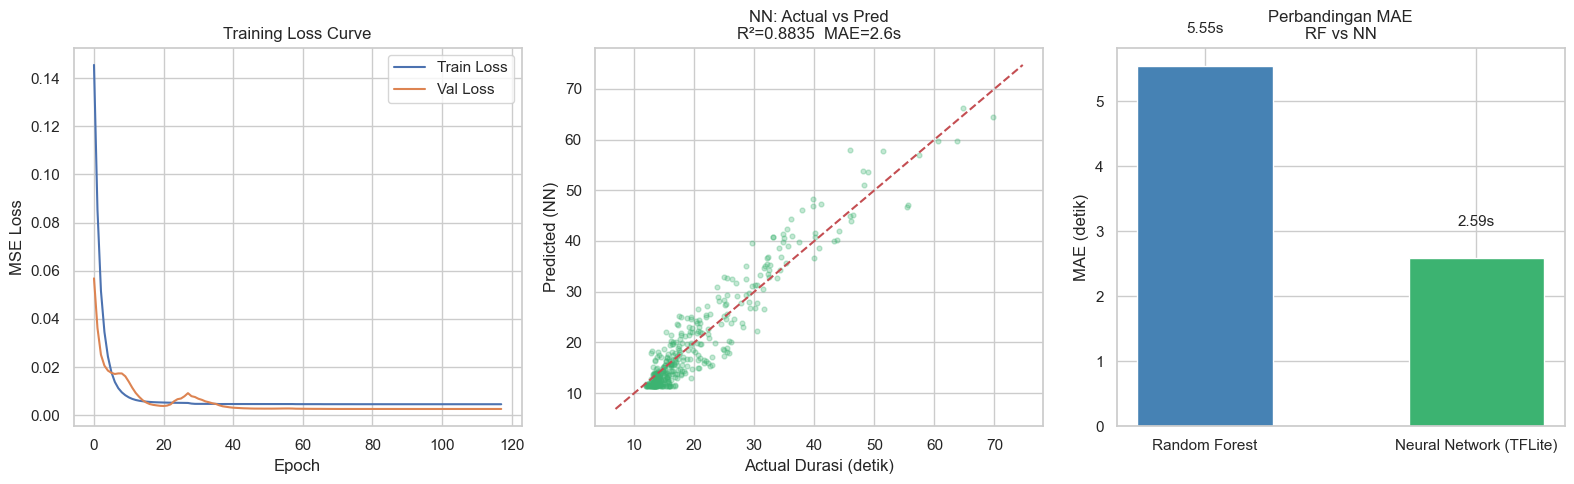

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss curve
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training Loss Curve', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# Actual vs Predicted NN
axes[1].scatter(y_true, y_pred_nn, alpha=0.3, s=12, color='mediumseagreen')
lim = [y_true.min()-5, y_true.max()+5]
axes[1].plot(lim, lim, 'r--', linewidth=1.5)
axes[1].set_xlabel('Actual Durasi (detik)')
axes[1].set_ylabel('Predicted (NN)')
axes[1].set_title(f'NN: Actual vs Pred\nR²={r2_nn:.4f}  MAE={mae_nn:.1f}s', fontsize=12)

# Perbandingan MAE: RF vs NN
bars = axes[2].bar(['Random Forest', 'Neural Network (TFLite)'],
                    [mae_rf, mae_nn],
                    color=['steelblue', 'mediumseagreen'], width=0.5)
axes[2].set_ylabel('MAE (detik)')
axes[2].set_title('Perbandingan MAE\nRF vs NN', fontsize=12)
for bar, val in zip(bars, [mae_rf, mae_nn]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.2f}s', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('eval_model2_nn.png', dpi=150)
plt.show()

## Cell 8 — Tahap ④ : Export ke TFLite (int8 Quantization)
Int8 quantization wajib untuk ESP32 — mengurangi ukuran model ~4× dan mempercepat inferensi.

In [10]:
# ── Simpan model Keras dulu ──
model.save('model2_nn_durasi.keras')
print('✅ Keras model disimpan → model2_nn_durasi.keras')

# ── Konversi ke TFLite float32 (referensi) ──
converter_f32 = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_f32    = converter_f32.convert()
with open('model2_durasi_f32.tflite', 'wb') as f:
    f.write(tflite_f32)
print(f'✅ TFLite float32 : {len(tflite_f32)/1024:.1f} KB → model2_durasi_f32.tflite')

# ── Konversi ke TFLite int8 (untuk ESP32) ──
def representative_dataset():
    """Sampel kalibrasi untuk quantization."""
    for i in range(200):
        sample = X_scaled[i:i+1].astype(np.float32)
        yield [sample]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type  = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8 = converter_int8.convert()
with open('model2_durasi_int8.tflite', 'wb') as f:
    f.write(tflite_int8)
print(f'✅ TFLite int8    : {len(tflite_int8)/1024:.1f} KB → model2_durasi_int8.tflite  ← UPLOAD INI KE ESP32')

print(f'\n📉 Kompresi      : {len(tflite_f32)/len(tflite_int8):.1f}× lebih kecil')

✅ Keras model disimpan → model2_nn_durasi.keras
INFO:tensorflow:Assets written to: /var/folders/yx/nxpxg23556v18ggjdd6phyq40000gn/T/tmp4f9roxht/assets


INFO:tensorflow:Assets written to: /var/folders/yx/nxpxg23556v18ggjdd6phyq40000gn/T/tmp4f9roxht/assets


: 

## Cell 9 — Validasi TFLite (Pastikan Output Konsisten)

In [ ]:
# Load dan test TFLite int8
interpreter = tf.lite.Interpreter(model_content=tflite_int8)
interpreter.allocate_tensors()

in_detail  = interpreter.get_input_details()[0]
out_detail = interpreter.get_output_details()[0]

# Ambil scale & zero_point untuk konversi int8 ↔ float
in_scale,  in_zero  = in_detail['quantization']
out_scale, out_zero = out_detail['quantization']

print(f'Input  dtype   : {in_detail["dtype"]}')
print(f'Output dtype   : {out_detail["dtype"]}')
print(f'Input  shape   : {in_detail["shape"]}')
print(f'Input  scale   : {in_scale:.6f},  zero_point: {in_zero}')
print(f'Output scale   : {out_scale:.6f}, zero_point: {out_zero}')

# Test inferensi 50 sampel
preds_tflite = []
preds_keras  = []

for i in range(50):
    x = X_scaled[i:i+1].astype(np.float32)

    # Quantize input float → int8
    x_int8 = (x / in_scale + in_zero).astype(np.int8)
    interpreter.set_tensor(in_detail['index'], x_int8)
    interpreter.invoke()
    out_int8 = interpreter.get_tensor(out_detail['index'])

    # Dequantize output int8 → float
    out_float = (out_int8.astype(np.float32) - out_zero) * out_scale
    durasi_pred = scaler_y.inverse_transform([[float(out_float.flatten()[0])]])[0][0]
    preds_tflite.append(durasi_pred)

    preds_keras.append(
        scaler_y.inverse_transform(model.predict(x, verbose=0))[0][0])

mae_tflite_vs_keras = mean_absolute_error(preds_keras, preds_tflite)
print(f'\n✅ MAE TFLite vs Keras (50 sampel): {mae_tflite_vs_keras:.2f} detik')
print('   (< 5 detik = akurasi TFLite bisa diterima untuk ESP32)')

## Cell 10 — Contoh Kode C++ untuk ESP32
Salin ini ke Arduino IDE / PlatformIO. Butuh library **EloquentTinyML** atau **TensorFlow Lite for Microcontrollers**.

In [ ]:
# Load parameter scaler
with open('scaler_params_durasi.json') as f:
    sp = json.load(f)

cpp_code = f"""
// ============================================================
// model2_durasi.h — Scaler & helper untuk TFLite ESP32
// Auto-generated dari Jupyter Notebook
// ============================================================
#pragma once

// Fitur input (urutan HARUS sama dengan training):
// {sp['features']}

const int   N_FEATURES   = {len(sp['features'])};

const float X_MIN[{len(sp['features'])}]   = {{ {', '.join(f'{v:.4f}f' for v in sp['X_min'])} }};
const float X_RANGE[{len(sp['features'])}] = {{ {', '.join(f'{v:.4f}f' for v in sp['X_range'])} }};

const float Y_MIN   = {sp['y_min']:.4f}f;
const float Y_RANGE = {sp['y_range']:.4f}f;

// Quantization params (dari TFLite int8)
const float INPUT_SCALE      = {in_scale:.8f}f;
const int   INPUT_ZERO_POINT = {in_zero};
const float OUTPUT_SCALE     = {out_scale:.8f}f;
const int   OUTPUT_ZERO_POINT= {out_zero};

// ── Normalisasi input sensor (MinMax) ──
void normalize_input(float* raw, int8_t* quantized) {{
    for (int i = 0; i < N_FEATURES; i++) {{
        float norm = (raw[i] - X_MIN[i]) / X_RANGE[i];          // [0, 1]
        norm = constrain(norm, 0.0f, 1.0f);
        quantized[i] = (int8_t)(norm / INPUT_SCALE + INPUT_ZERO_POINT);
    }}
}}

// ── Denormalisasi output NN → durasi (detik) ──
float denormalize_output(int8_t q_val) {{
    float norm = ((float)q_val - OUTPUT_ZERO_POINT) * OUTPUT_SCALE;  // [0, 1]
    return norm * Y_RANGE + Y_MIN;                                    // detik
}}

// ── Contoh pemakaian di loop() ──
// float sensor[7] = {{ kelembapan_tanah, kelembapan_udara, suhu,
//                      vpd, ec_aktual, debit_pompa, fase }};
// int8_t input_q[7];
// normalize_input(sensor, input_q);
// tflite_interpreter->input(0)->data.int8 = input_q;  // set input
// tflite_interpreter->Invoke();
// int8_t output_q = tflite_interpreter->output(0)->data.int8[0];
// float durasi_detik = denormalize_output(output_q);
// Serial.printf(\"Durasi penyiraman: %.1f detik\\n\", durasi_detik);
"""

with open('model2_durasi.h', 'w') as f:
    f.write(cpp_code)

print(cpp_code)
print('✅ Header disimpan → model2_durasi.h')

## Cell 11 — Ringkasan Output File

| File | Keterangan |
|---|---|
| `dataset_durasi_penyiraman.csv` | Dataset sintetis |
| `model2_rf_durasi.pkl` | RF model (referensi/analisis) |
| `model2_nn_durasi.keras` | Keras NN model |
| `model2_durasi_f32.tflite` | TFLite float32 |
| **`model2_durasi_int8.tflite`** | **TFLite int8 → upload ke ESP32** |
| `scaler_X_durasi.pkl` | Scaler fitur (Python) |
| `scaler_y_durasi.pkl` | Scaler target (Python) |
| `scaler_params_durasi.json` | Parameter scaler (C++/ESP32) |
| **`model2_durasi.h`** | **Header C++ untuk ESP32** |

In [ ]:
import os
files = [
    'dataset_durasi_penyiraman.csv',
    'model2_rf_durasi.pkl',
    'model2_nn_durasi.keras',
    'model2_durasi_f32.tflite',
    'model2_durasi_int8.tflite',
    'scaler_params_durasi.json',
    'model2_durasi.h'
]
print('=== Output Files ===')
for fn in files:
    size = os.path.getsize(fn)/1024 if os.path.exists(fn) else 0
    tag  = ' ← ESP32' if 'int8' in fn or fn.endswith('.h') else ''
    print(f'  {fn:<40} {size:6.1f} KB{tag}')